# DSA4266 Group 2 — Logistic Regression Baseline (Sub-problem A)

This notebook implements the **Logistic Regression with N-gram Features** baseline classifier for DGA detection.  
It is intentionally the simplest model in the pipeline — its role is to establish a reference point for FPR, AUC-ROC, inference latency, and parameter count against which all subsequent models must justify their additional complexity.

### Sections
1. Setup & Data Loading  
2. Data Exploration  
3. Data Cleaning  
4. Feature Engineering (Character-level TF-IDF N-grams)  
5. Model Training — BCE, Weighted BCE, Focal Loss  
6. Threshold Calibration & ROC Analysis  
7. Evaluation Metrics  
8. Inference Latency & Parameter Count  
9. Leave-One-Family-Out Robustness Evaluation  
10. Feature Interpretability  

What the Logistic Regression Coder Needs to Do — In Detail
The member responsible for this baseline model has one of the most foundational jobs on the team. Here is precisely what they need to implement:
1. Feature Engineering — Converting Website Names into Numbers
A model can't read text directly, so the coder must first transform each domain string into a numerical representation using character-level n-gram TF-IDF.
Here's what that means step by step:

Character-level n-grams: Break each domain name into all overlapping substrings of length 2, 3, and 4. For example, the domain google would produce bigrams like go, oo, og, gl, le; trigrams like goo, oog, ogl, gle; and 4-grams like goog, oogl, ogle. This creates a large vocabulary of character patterns.
TF-IDF weighting: Not all character patterns are equally useful. A pattern that appears in almost every domain name tells you nothing useful. TF-IDF automatically assigns lower weight to common, uninformative patterns and higher weight to rare, distinctive ones. The coder must apply sklearn's TfidfVectorizer with analyzer='char' and ngram_range=(2,4).
The final output is a sparse numerical vector for each domain name — a long list of numbers representing how characteristic each character pattern is for that specific domain.

2. Training the Logistic Regression Classifier
Once each domain is a numerical vector, the coder trains a logistic regression model. Logistic regression works by learning a weight for every single n-gram feature, then combining all the weighted pattern scores into a single probability between 0 and 1 — the probability that the domain is malicious.
Concretely, the coder must:

Use Binary Cross-Entropy (BCE) as the loss function (sklearn's LogisticRegression does this by default)
Also train a version with class weighting (class_weight parameter) to penalise false positives more heavily
Experiment with Focal Loss as an alternative — this requires either a custom implementation or using a library like scikit-learn with a custom loss wrapper, since focal loss is not natively in sklearn. They may need to use SGDClassifier with a custom loss or implement it via PyTorch/a small neural network equivalent

3. Threshold Calibration
By default, the model flags a domain as malicious if its predicted probability exceeds 0.5. The coder must implement post-training threshold tuning — sweeping the threshold from 0 to 1 and plotting how FPR and recall change at each threshold. This gives the security team the ability to choose their preferred operating point (e.g., prioritise catching more hackers vs. minimising false alarms on innocent websites).
4. Evaluation — Sub-problem A Metrics
The coder must compute and report:

AUC-ROC curve — plot TPR vs FPR across all thresholds
Precision, Recall, F1-score at the chosen threshold
FPR explicitly
Inference latency — time how long it takes to classify one domain and report average + worst-case times
Parameter/feature count — report the size of the TF-IDF vocabulary and the number of model weights

5. Robustness Evaluation — Leave-One-Family-Out
This is critical. The coder must implement a loop that:

Identifies all DGA malware family labels in the dataset
For each family, removes it from the training set entirely
Retrains the logistic regression from scratch on the remaining data
Tests performance specifically on the held-out family
Records the F1 score drop compared to the full-data model

This produces a per-family generalization gap that shows which malware families the model struggles with when it hasn't seen them before.
6. Feature Interpretability
Since logistic regression is fully interpretable, the coder should extract and report the top positive and negative weight n-grams — the character patterns most strongly associated with malicious vs. legitimate domains. For example, it's likely that n-grams like xkq or zzt are strong malicious indicators, while www or com are benign indicators. This interpretability is one of the key reasons logistic regression is used as the baseline.
7. Outputs to Hand Off to the Team
The coder's deliverables to the rest of the group should include:

A trained, saved model file (the baseline others will compare against)
The AUC-ROC score and FPR at various thresholds
Latency benchmarks and parameter count
Leave-one-family-out F1 scores per family
The threshold vs. FPR calibration curve
A list of the most informative n-gram features

## 1. Setup & Data Loading

In [1]:
# Uncomment if needed:
# !pip install kagglehub scikit-learn torch matplotlib seaborn pandas numpy

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import time
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    f1_score, precision_score, recall_score, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("gtkcyber/dga-dataset")
print("Dataset path:", path)

# Locate the CSV file automatically
csv_path = None
for fname in os.listdir(path):
    if fname.endswith('.csv'):
        csv_path = os.path.join(path, fname)
        print("Found CSV:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No CSV found in downloaded dataset.")

Dataset path: C:\Users\ryanc\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1
Found CSV: C:\Users\ryanc\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1\dga_data.csv


## 2. Data Exploration

In [4]:
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\n--- Label Distribution ---")
print(df['isDGA'].value_counts())

print("\n--- DGA Subclass Distribution (top 20) ---")
dga_rows = df[df['isDGA'] == 'dga']
print(dga_rows['subclass'].value_counts().head(20))

print("\n--- Missing values ---")
print(df.isnull().sum())

Shape: (160000, 4)

Columns: ['isDGA', 'domain', 'host', 'subclass']

First 5 rows:


,isDGA,domain,host,subclass
0,dga,6xzxsw3sokvg1tc752y1a6p0af,6xzxsw3sokvg1tc752y1a6p0af.com,gameoverdga
1,dga,glbtlxwwhbnpxs,glbtlxwwhbnpxs.ru,cryptolocker
2,dga,xxmamopyipbfpk,xxmamopyipbfpk.ru,cryptolocker
3,dga,zfd5szpi18i85wj9uy13l69rg,zfd5szpi18i85wj9uy13l69rg.net,newgoz
4,dga,jpqftymiuver,jpqftymiuver.ru,cryptolocker



--- Label Distribution ---
isDGA
dga      80000
legit    80000
Name: count, dtype: int64

--- DGA Subclass Distribution (top 20) ---
subclass
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64

--- Missing values ---
isDGA       0
domain      2
host        0
subclass    0
dtype: int64


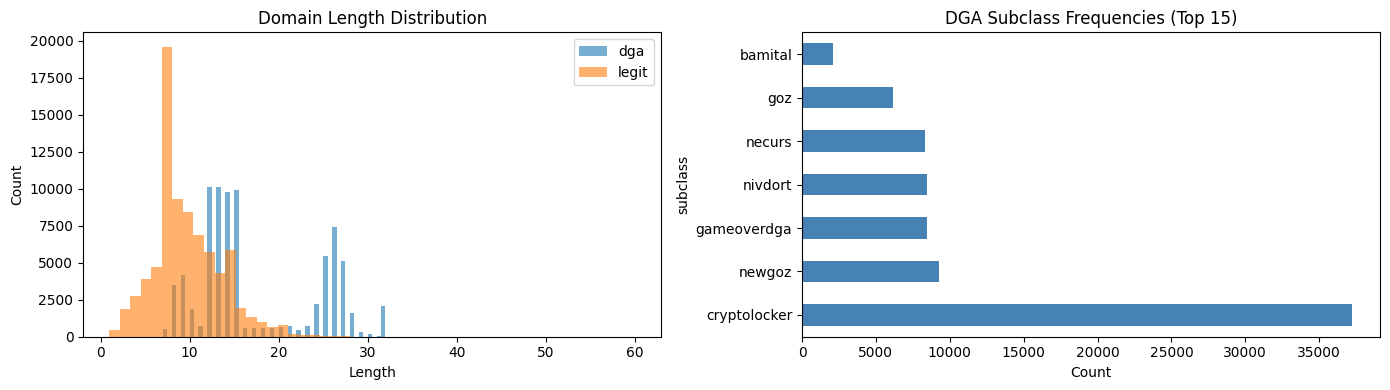

In [5]:
df['domain_length'] = df['domain'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, group in df.groupby('isDGA'):
    axes[0].hist(group['domain_length'], bins=50, alpha=0.6, label=label)
axes[0].set_title('Domain Length Distribution')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Count')
axes[0].legend()

dga_rows['subclass'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('DGA Subclass Frequencies (Top 15)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

**Critical design decision:** Per the project proposal, detection must rely *purely on lexical patterns* from the raw domain string. We therefore use **only the `domain` column** as input.

- Including `host` would be redundant — it is simply `domain + TLD`, carrying no additional signal.
- Including `subclass` would be **label leakage** — it directly identifies the malware family and is not available at inference time in a real deployment.

In [6]:
# Drop rows with missing domain
df = df.dropna(subset=['domain']).copy()
df['domain'] = df['domain'].str.lower().str.strip()

# Encode binary label: legit=0, dga=1
df['label'] = df['isDGA'].map({'legit': 0, 'dga': 1})
assert df['label'].isnull().sum() == 0, "Unexpected label values — check isDGA column."

# Feature: domain string only
# subclass retained as a separate series for robustness evaluation — it is NOT a model input
X        = df['domain']
y        = df['label']
subclass = df['subclass'].fillna('legit')

print(f"Total samples : {len(df):,}")
print(f"DGA           : {y.sum():,}")
print(f"Legit         : {(1-y).sum():,}")

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test, sub_train, sub_test = train_test_split(
    X, y, subclass,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")

Total samples : 159,998
DGA           : 80,000
Legit         : 79,998

Train size : 127,998
Test size  : 32,000


## 4. Feature Engineering — Character-level TF-IDF N-grams

Each domain string is treated as a short character sequence. We extract all overlapping substrings of length 2–4 (bigrams, trigrams, 4-grams) and weight them by TF-IDF.  

TF-IDF down-weights character patterns common across all domains and up-weights those distinctive to individual samples — making it well-suited for detecting the unusual character distributions typical of algorithmically generated names.

> **Memory note:** The resulting matrix is kept **sparse**. Converting it to a dense PyTorch tensor (100k features × 128k samples × 4 bytes ≈ 51 GB) would crash any standard machine. Dense conversion is only done per-batch inside the focal loss dataloader.

In [7]:
vectorizer = TfidfVectorizer(
    analyzer='char',        # character-level n-grams (not word-level)
    ngram_range=(2, 4),     # bigrams, trigrams, 4-grams as specified in the proposal
    lowercase=True,
    max_features=100_000,   # cap vocabulary to 100k most informative n-grams
    sublinear_tf=True       # apply log(1+tf) to compress high-frequency counts
)

# Fit ONLY on training data to prevent data leakage
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"Vocabulary size : {len(vectorizer.vocabulary_):,} n-grams")
print(f"Train matrix    : {X_train_vec.shape[0]:,} x {X_train_vec.shape[1]:,}  (sparse)")
print(f"Test  matrix    : {X_test_vec.shape[0]:,} x {X_test_vec.shape[1]:,}  (sparse)")
sparsity = 1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])
print(f"Sparsity        : {sparsity:.4%}")

Vocabulary size : 100,000 n-grams
Train matrix    : 127,998 x 100,000  (sparse)
Test  matrix    : 32,000 x 100,000  (sparse)
Sparsity        : 99.9720%


## 5. Model Training — Comparing Loss Functions

We train and compare three variants as specified in the proposal:

| Variant | Loss | Rationale |
|---|---|---|
| **LR-BCE** | Binary Cross-Entropy | Standard baseline |
| **LR-WBCE** | Weighted BCE | Higher penalty on false positives |
| **LR-Focal** | Focal Loss (γ=2, α=0.25) | Focuses training on hard/ambiguous examples |

In [8]:
# --- Variant 1: Standard BCE ---
# sklearn's LogisticRegression minimises log-loss (equivalent to BCE) by default
print("Training LR-BCE...")
t0 = time.time()
lr_bce = LogisticRegression(
    solver='saga',       # efficient solver for large sparse inputs
    max_iter=1000,
    C=1.0,               # inverse of L2 regularisation strength
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_bce.fit(X_train_vec, y_train)

bce_iterations = lr_bce.n_iter_[0]

print(f"LR-BCE converged in {bce_iterations} iterations")
print(f"  Done in {time.time()-t0:.1f}s")

Training LR-BCE...
LR-BCE converged in 20 iterations
  Done in 1.8s


In [9]:
# --- Variant 2: Weighted BCE ---
# class_weight={0: w, 1: 1} applies a w× penalty when misclassifying a legit domain (class 0),
# directly reducing FPR at the cost of some recall on DGA.
print("Training LR-WBCE (class_weight={0: 3, 1: 1})...")
t0 = time.time()
lr_wbce = LogisticRegression(
    solver='saga',
    max_iter=1000,
    C=1.0,
    class_weight={0: 3, 1: 1},   # 3x penalty for false positives; tune as needed
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_wbce.fit(X_train_vec, y_train)
wbce_iterations = lr_wbce.n_iter_[0]

print(f"LR-WBCE converged in {wbce_iterations} iterations")
print(f"  Done in {time.time()-t0:.1f}s")

Training LR-WBCE (class_weight={0: 3, 1: 1})...
LR-WBCE converged in 27 iterations
  Done in 2.4s


In [10]:
# --- Variant 3: Focal Loss ---
# Focal loss is not available in sklearn, so we implement a minimal logistic regression
# in PyTorch. The sparse matrix is fed in mini-batches to avoid materialising the
# full dense tensor (~51 GB) in memory.

class SparseBatchDataset(Dataset):
    """Converts sparse matrix rows to dense tensors on demand (lazy, memory-efficient)."""
    def __init__(self, X_sparse, y_array):
        self.X = X_sparse
        self.y = y_array.astype(np.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].toarray().squeeze(), dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x, y


class FocalLoss(nn.Module):
    """
    Focal loss (Lin et al., 2017).
    Introduces a modulating factor (1-p_t)^gamma that down-weights easy,
    confidently-classified examples and focuses training on hard ambiguous ones.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce   = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs    = torch.sigmoid(logits)
        p_t      = targets * probs + (1 - targets) * (1 - probs)
        focal_w  = (1 - p_t) ** self.gamma
        return (self.alpha * focal_w * bce_loss).mean()


class TorchLogisticRegression(nn.Module):
    """Single linear layer — mathematically identical to logistic regression."""
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1)   # raw logits

print("Focal loss classes defined.")

Focal loss classes defined.


In [11]:
print("Training LR-Focal (may take several minutes on CPU)...")

device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {device}")

focal_model   = TorchLogisticRegression(X_train_vec.shape[1]).to(device)
focal_crit    = FocalLoss(alpha=0.25, gamma=2.0)
optimizer     = torch.optim.Adam(focal_model.parameters(), lr=1e-3)

train_ds      = SparseBatchDataset(X_train_vec, y_train.values)
train_loader  = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=0)

EPOCHS = 10
for epoch in range(EPOCHS):
    focal_model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = focal_crit(focal_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1:02d}/{EPOCHS}  Loss: {total_loss/len(train_loader):.5f}")

print("  Training complete.")

Training LR-Focal (may take several minutes on CPU)...
  Using device: cpu
  Epoch 01/10  Loss: 0.03382
  Epoch 02/10  Loss: 0.02276
  Epoch 03/10  Loss: 0.01759
  Epoch 04/10  Loss: 0.01456
  Epoch 05/10  Loss: 0.01252
  Epoch 06/10  Loss: 0.01103
  Epoch 07/10  Loss: 0.00986
  Epoch 08/10  Loss: 0.00892
  Epoch 09/10  Loss: 0.00814
  Epoch 10/10  Loss: 0.00747
  Training complete.


In [12]:
# Collect focal model probabilities on test set
focal_model.eval()
test_ds      = SparseBatchDataset(X_test_vec, y_test.values)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)

focal_probs_list  = []
focal_labels_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.sigmoid(focal_model(X_batch.to(device))).cpu().numpy()
        focal_probs_list.extend(probs)
        focal_labels_list.extend(y_batch.numpy())

focal_probs = np.array(focal_probs_list)
print(f"Focal predictions collected: {len(focal_probs):,} test samples")

Focal predictions collected: 32,000 test samples


## 6. Threshold Calibration & ROC Analysis

The default 0.5 decision threshold is rarely optimal in deployment. We sweep the full threshold range and produce:
- **AUC-ROC** — threshold-independent discriminative ability  
- **Threshold vs FPR curve** — lets the operator select the threshold that satisfies their FPR budget

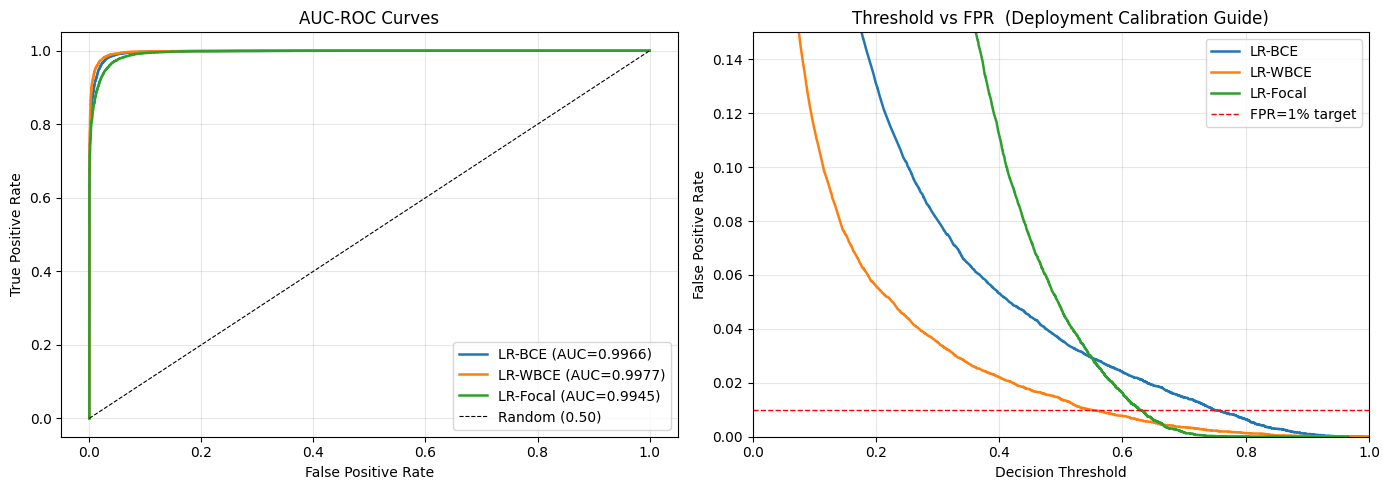

Saved: roc_curves.png


In [13]:
probs_bce   = lr_bce.predict_proba(X_test_vec)[:, 1]
probs_wbce  = lr_wbce.predict_proba(X_test_vec)[:, 1]
true_labels = y_test.values

models = {
    'LR-BCE'   : probs_bce,
    'LR-WBCE'  : probs_wbce,
    'LR-Focal' : focal_probs
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- AUC-ROC ---
for name, probs in models.items():
    fpr_arr, tpr_arr, _ = roc_curve(true_labels, probs)
    roc_auc = auc(fpr_arr, tpr_arr)
    axes[0].plot(fpr_arr, tpr_arr, linewidth=1.8, label=f"{name} (AUC={roc_auc:.4f})")
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('AUC-ROC Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Threshold vs FPR calibration ---
for name, probs in models.items():
    fpr_arr, _, thresholds = roc_curve(true_labels, probs)
    axes[1].plot(thresholds, fpr_arr, linewidth=1.8, label=name)
axes[1].axhline(y=0.01, color='red', linestyle='--', linewidth=1, label='FPR=1% target')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('False Positive Rate')
axes[1].set_title('Threshold vs FPR  (Deployment Calibration Guide)')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 0.15)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

In [14]:
def select_threshold_at_fpr(true_labels, probs, target_fpr=0.01):
    """Return the highest threshold that keeps FPR at or below target_fpr."""
    fpr_arr, tpr_arr, thresholds = roc_curve(true_labels, probs)
    valid = np.where(fpr_arr <= target_fpr)[0]
    if len(valid) == 0:
        return 0.5, None, None
    idx = valid[-1]
    return float(thresholds[idx]), float(fpr_arr[idx]), float(tpr_arr[idx])

TARGET_FPR = 0.01   # 1% FPR operational budget

thresholds_chosen = {}
print(f"{'Model':<12} {'Threshold':>10} {'Actual FPR':>12} {'Recall (TPR)':>14}")
print("-" * 52)
for name, probs in models.items():
    t, fpr_at_t, tpr_at_t = select_threshold_at_fpr(true_labels, probs, TARGET_FPR)
    thresholds_chosen[name] = t
    print(f"{name:<12} {t:>10.4f} {fpr_at_t:>12.4f} {tpr_at_t:>14.4f}")

Model         Threshold   Actual FPR   Recall (TPR)
----------------------------------------------------
LR-BCE           0.7487       0.0100         0.9144
LR-WBCE          0.5469       0.0100         0.9481
LR-Focal         0.6276       0.0100         0.8690


## 7. Evaluation Metrics

In [15]:
def evaluate(name, probs, true_labels, threshold):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_labels, y_pred).ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fpr_arr, tpr_arr, _ = roc_curve(true_labels, probs)
    return {
        'Model'    : name,
        'Threshold': round(threshold, 4),
        'AUC-ROC'  : round(auc(fpr_arr, tpr_arr), 4),
        'FPR'      : round(fpr_val, 4),
        'Precision': round(precision_score(true_labels, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(true_labels, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(true_labels, y_pred, zero_division=0), 4),
    }, y_pred

results   = []
preds_all = {}
for name, probs in models.items():
    r, y_pred = evaluate(name, probs, true_labels, thresholds_chosen[name])
    results.append(r)
    preds_all[name] = y_pred

results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison ===")
display(results_df)

# Detailed report for the best-AUC model
best_name  = results_df['AUC-ROC'].idxmax()
best_preds = preds_all[best_name]
print(f"\n=== Detailed Classification Report: {best_name} ===")
print(classification_report(true_labels, best_preds, target_names=['Legit', 'DGA']))

=== Model Comparison ===


,Threshold,AUC-ROC,FPR,Precision,Recall,F1
Model,,,,,,
LR-BCE,0.7487,0.9966,0.01,0.9892,0.9144,0.9503
LR-WBCE,0.5469,0.9977,0.01,0.9896,0.9481,0.9684
LR-Focal,0.6276,0.9945,0.01,0.9886,0.8690,0.9250



=== Detailed Classification Report: LR-WBCE ===
              precision    recall  f1-score   support

       Legit       0.95      0.99      0.97     16000
         DGA       0.99      0.95      0.97     16000

    accuracy                           0.97     32000
   macro avg       0.97      0.97      0.97     32000
weighted avg       0.97      0.97      0.97     32000



## 8. Inference Latency & Parameter Count

Operational constraints require measuring both average and **tail (P99)** latency per domain, plus total parameter count.

In [16]:
N_SAMPLES  = 500
sample_idx = np.random.choice(len(X_test), N_SAMPLES, replace=False)
X_sample   = [X_test.iloc[i] for i in sample_idx]

def measure_latency_sklearn(model, vec, samples, n_repeats=3):
    latencies = []
    for _ in range(n_repeats):
        for domain in samples:
            t0 = time.perf_counter()
            _  = model.predict_proba(vec.transform([domain]))[0, 1]
            latencies.append((time.perf_counter() - t0) * 1000)
    return np.array(latencies)

def measure_latency_torch(model, vec, samples, dev, n_repeats=3):
    model.eval()
    latencies = []
    with torch.no_grad():
        for _ in range(n_repeats):
            for domain in samples:
                t0 = time.perf_counter()
                x  = torch.tensor(vec.transform([domain]).toarray(), dtype=torch.float32).to(dev)
                _  = torch.sigmoid(model(x)).item()
                latencies.append((time.perf_counter() - t0) * 1000)
    return np.array(latencies)

lat = {
    'LR-BCE'   : measure_latency_sklearn(lr_bce,  vectorizer, X_sample),
    'LR-WBCE'  : measure_latency_sklearn(lr_wbce, vectorizer, X_sample),
    'LR-Focal' : measure_latency_torch(focal_model, vectorizer, X_sample, device)
}

print(f"{'Model':<12} {'Mean (ms)':>10} {'Median':>8} {'P99 (ms)':>10} {'Max (ms)':>10}")
print("-" * 54)
for name, lats in lat.items():
    print(f"{name:<12} {np.mean(lats):>10.3f} {np.median(lats):>8.3f} "
          f"{np.percentile(lats,99):>10.3f} {np.max(lats):>10.3f}")

Model         Mean (ms)   Median   P99 (ms)   Max (ms)
------------------------------------------------------
LR-BCE            0.297    0.273      0.582      1.064
LR-WBCE           0.273    0.253      0.511      0.776
LR-Focal          0.725    0.683      1.264      2.319


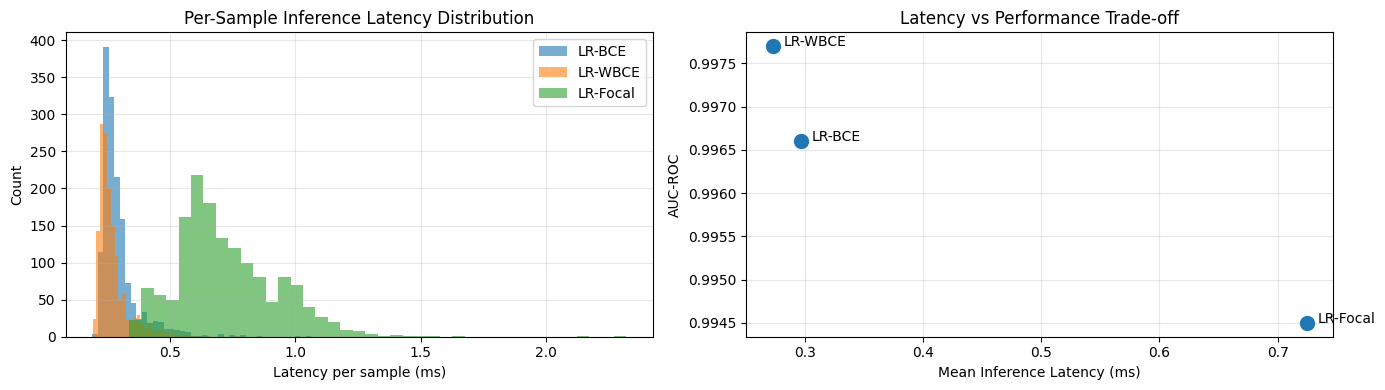

Saved: latency_analysis.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, lats in lat.items():
    axes[0].hist(lats, bins=40, alpha=0.6, label=name)
axes[0].set_xlabel('Latency per sample (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-Sample Inference Latency Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

mean_lats = [np.mean(lat[n]) for n in results_df.index]
auc_vals  = results_df['AUC-ROC'].values
axes[1].scatter(mean_lats, auc_vals, s=100, zorder=5)
for i, name in enumerate(results_df.index):
    axes[1].annotate(name, (mean_lats[i], auc_vals[i]),
                     textcoords='offset points', xytext=(8, 0))
axes[1].set_xlabel('Mean Inference Latency (ms)')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Latency vs Performance Trade-off')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latency_analysis.png")

In [18]:
vocab_size     = len(vectorizer.vocabulary_)
n_params_lr    = vocab_size + 1                                      # weights + bias
n_params_torch = sum(p.numel() for p in focal_model.parameters())

print("=== Model Size ===")
print(f"TF-IDF vocabulary     : {vocab_size:>10,} n-grams")
print(f"LR-BCE  parameters    : {n_params_lr:>10,}  (1 weight per n-gram + bias)")
print(f"LR-WBCE parameters    : {n_params_lr:>10,}  (1 weight per n-gram + bias)")
print(f"LR-Focal parameters   : {n_params_torch:>10,}  (PyTorch linear layer)")

=== Model Size ===
TF-IDF vocabulary     :    100,000 n-grams
LR-BCE  parameters    :    100,001  (1 weight per n-gram + bias)
LR-WBCE parameters    :    100,001  (1 weight per n-gram + bias)
LR-Focal parameters   :    100,001  (PyTorch linear layer)


## 9. Leave-One-Family-Out Robustness Evaluation

For each DGA malware family:
1. Remove all of that family's samples from the training set  
2. Retrain LR-BCE from scratch on the reduced set  
3. Evaluate F1 only on that held-out family in the test set  

The **generalisation gap** = (baseline F1 on full data) − (LOFO F1) quantifies how much performance degrades when the model has never seen that family. Families with large gaps are where the system is most vulnerable to novel DGA behaviour.

In [19]:
dga_families = sorted(df[df['isDGA'] == 'dga']['subclass'].dropna().unique())
print(f"DGA families: {len(dga_families)}")
print(dga_families)

# Per-family baseline F1 (model trained on ALL families)
baseline_preds_arr = preds_all['LR-BCE']
baseline_f1 = {}
for family in dga_families:
    mask = (sub_test == family).values
    if mask.sum() == 0:
        continue
    baseline_f1[family] = round(f1_score(true_labels[mask], baseline_preds_arr[mask], zero_division=0), 4)

print("\nBaseline F1 per family (trained on all data):")
for fam, f1 in sorted(baseline_f1.items(), key=lambda x: x[1]):
    print(f"  {fam:<30} {f1:.4f}")

DGA families: 7
['bamital', 'cryptolocker', 'gameoverdga', 'goz', 'necurs', 'newgoz', 'nivdort']

Baseline F1 per family (trained on all data):
  nivdort                        0.8076
  necurs                         0.9444
  cryptolocker                   0.9566
  newgoz                         0.9948
  gameoverdga                    0.9971
  goz                            0.9972
  bamital                        1.0000


In [20]:
lofo_results = []

for family in dga_families:
    # Remove this family from training
    keep_mask   = (sub_train != family)
    X_lofo_raw  = X_train[keep_mask]
    y_lofo      = y_train[keep_mask]

    # Re-fit a fresh vectorizer (must not leak held-out family's n-grams)
    vec_lofo = TfidfVectorizer(
        analyzer='char', ngram_range=(2, 4),
        lowercase=True, max_features=100_000, sublinear_tf=True
    )
    X_lofo_vec = vec_lofo.fit_transform(X_lofo_raw)

    lr_lofo = LogisticRegression(
        solver='saga', max_iter=500, C=1.0,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    lr_lofo.fit(X_lofo_vec, y_lofo)

    # Test on this family only
    test_mask = (sub_test == family).values
    if test_mask.sum() == 0:
        continue

    X_held_vec = vec_lofo.transform(X_test[test_mask])
    y_held     = y_test[test_mask]
    preds_held = (lr_lofo.predict_proba(X_held_vec)[:, 1] >= 0.5).astype(int)
    f1_lofo    = f1_score(y_held, preds_held, zero_division=0)
    baseline   = baseline_f1.get(family, 0.0)
    gap        = round(baseline - f1_lofo, 4)

    lofo_results.append({
        'Family'             : family,
        'LOFO F1'            : round(f1_lofo, 4),
        'Baseline F1'        : baseline,
        'Generalisation Gap' : gap,
        'N test samples'     : int(test_mask.sum())
    })
    print(f"  {family:<30}  LOFO={f1_lofo:.4f}  Baseline={baseline:.4f}  Gap={gap:+.4f}")

lofo_df = pd.DataFrame(lofo_results).sort_values('Generalisation Gap', ascending=False)
display(lofo_df)

  bamital                         LOFO=0.9963  Baseline=1.0000  Gap=+0.0037
  cryptolocker                    LOFO=0.9354  Baseline=0.9566  Gap=+0.0212
  gameoverdga                     LOFO=1.0000  Baseline=0.9971  Gap=-0.0029
  goz                             LOFO=0.9992  Baseline=0.9972  Gap=-0.0020
  necurs                          LOFO=0.9811  Baseline=0.9444  Gap=-0.0367
  newgoz                          LOFO=1.0000  Baseline=0.9948  Gap=-0.0052
  nivdort                         LOFO=0.0000  Baseline=0.8076  Gap=+0.8076


,Family,LOFO F1,Baseline F1,Generalisation Gap,N test samples
6,nivdort,0.0000,0.8076,0.8076,1655
1,cryptolocker,0.9354,0.9566,0.0212,7420
0,bamital,0.9963,1.0000,0.0037,405
3,goz,0.9992,0.9972,-0.0020,1249
2,gameoverdga,1.0000,0.9971,-0.0029,1704
5,newgoz,1.0000,0.9948,-0.0052,1838
4,necurs,0.9811,0.9444,-0.0367,1729


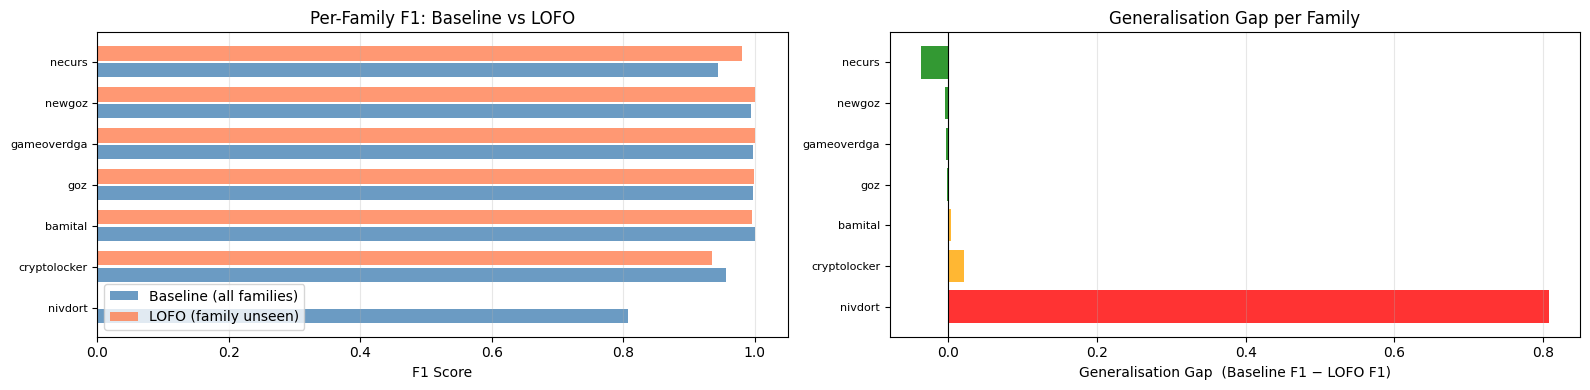

Saved: lofo_analysis.png

Per-family F1 variance (LOFO) : 0.139240
Mean generalisation gap        : 0.1122


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(lofo_df) * 0.35 + 1)))

y_pos = np.arange(len(lofo_df))

axes[0].barh(y_pos - 0.2, lofo_df['Baseline F1'], 0.35,
             label='Baseline (all families)', color='steelblue', alpha=0.8)
axes[0].barh(y_pos + 0.2, lofo_df['LOFO F1'], 0.35,
             label='LOFO (family unseen)', color='coral', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(lofo_df['Family'], fontsize=8)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('Per-Family F1: Baseline vs LOFO')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

colors = ['red' if g > 0.1 else 'orange' if g > 0 else 'green'
          for g in lofo_df['Generalisation Gap']]
axes[1].barh(y_pos, lofo_df['Generalisation Gap'], color=colors, alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(lofo_df['Family'], fontsize=8)
axes[1].set_xlabel('Generalisation Gap  (Baseline F1 − LOFO F1)')
axes[1].set_title('Generalisation Gap per Family')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lofo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lofo_analysis.png")

print(f"\nPer-family F1 variance (LOFO) : {lofo_df['LOFO F1'].var():.6f}")
print(f"Mean generalisation gap        : {lofo_df['Generalisation Gap'].mean():.4f}")

## 10. Feature Interpretability

A key advantage of logistic regression is that every weight directly corresponds to a specific character n-gram. We extract the top positive (DGA-indicating) and top negative (benign-indicating) n-grams to understand what lexical patterns the model has learned to rely on.

In [22]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients  = lr_bce.coef_[0]    # one weight per n-gram

TOP_N = 25
top_dga_idx    = np.argsort(coefficients)[-TOP_N:][::-1]
top_benign_idx = np.argsort(coefficients)[:TOP_N]

top_dga    = list(zip(feature_names[top_dga_idx],    coefficients[top_dga_idx]))
top_benign = list(zip(feature_names[top_benign_idx], coefficients[top_benign_idx]))

print("Top 25 DGA-indicating n-grams (positive weights):")
for ngram, w in top_dga:
    print(f"  {repr(ngram):<12}  {w:+.4f}")

print("\nTop 25 Benign-indicating n-grams (negative weights):")
for ngram, w in top_benign:
    print(f"  {repr(ngram):<12}  {w:+.4f}")

Top 25 DGA-indicating n-grams (positive weights):
  'went'        +6.3500
  'kg'          +5.9207
  'eq'          +5.8723
  'ariv'        +5.8073
  'pq'          +5.7829
  'made'        +5.7722
  'wr'          +5.6698
  'case'        +5.6685
  'bq'          +5.5470
  'vj'          +5.5361
  'vl'          +5.5333
  'fk'          +5.4577
  'qb'          +5.4444
  'then'        +5.4393
  'aq'          +5.4358
  'salt'        +5.4289
  'qa'          +5.3823
  'xk'          +5.3739
  'rq'          +5.3727
  'kn'          +5.3718
  'nq'          +5.3507
  'qo'          +5.3140
  'most'        +5.2809
  'qg'          +5.2702
  'fq'          +5.2291

Top 25 Benign-indicating n-grams (negative weights):
  'er'          -5.5191
  'web'         -5.2837
  'in'          -5.0441
  'an'          -4.9589
  'you'         -4.0230
  'pro'         -4.0186
  'for'         -3.8432
  'net'         -3.6872
  'cdn'         -3.6792
  'log'         -3.6099
  'li'          -3.5649
  'new'         -3.4733
  'che' 

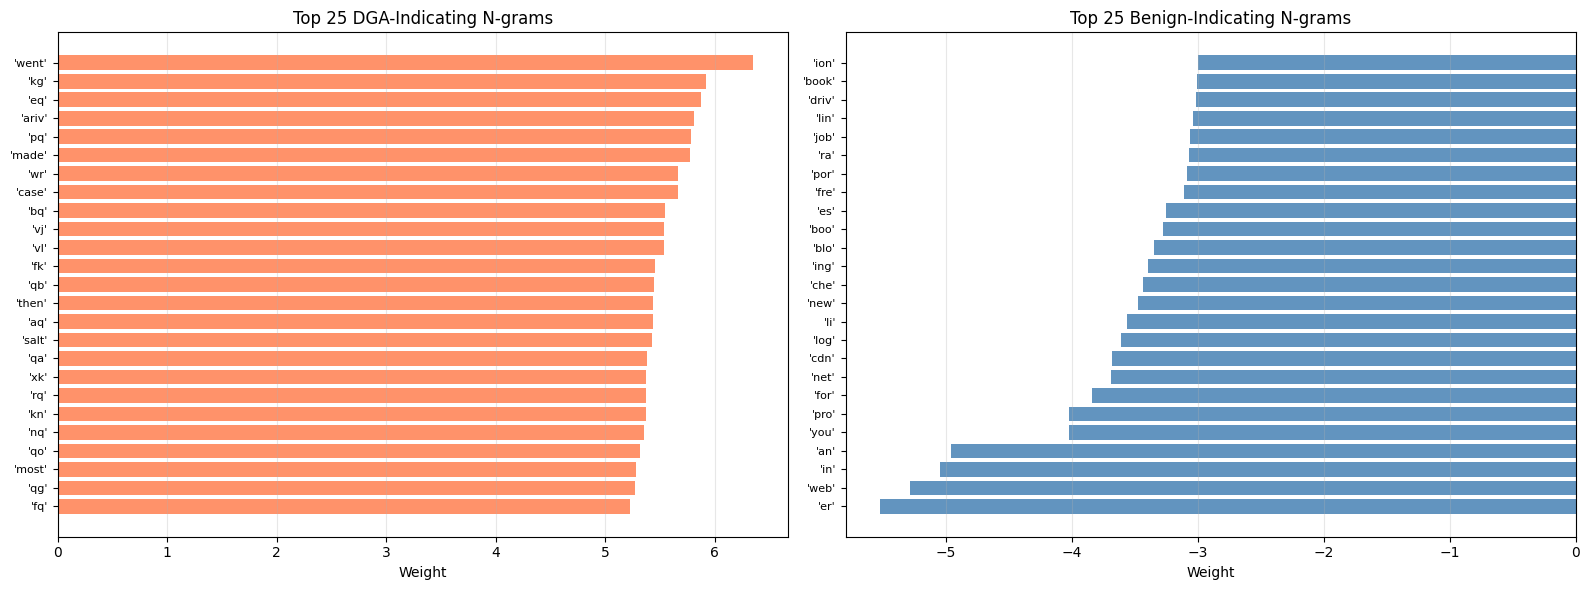

Saved: feature_importance.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dga_ngrams,    dga_weights    = zip(*top_dga)
benign_ngrams, benign_weights = zip(*top_benign)

axes[0].barh(range(TOP_N), list(reversed(dga_weights)), color='coral', alpha=0.85)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels([repr(n) for n in reversed(dga_ngrams)], fontsize=8)
axes[0].set_xlabel('Weight')
axes[0].set_title('Top 25 DGA-Indicating N-grams')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(range(TOP_N), benign_weights, color='steelblue', alpha=0.85)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels([repr(n) for n in benign_ngrams], fontsize=8)
axes[1].set_xlabel('Weight')
axes[1].set_title('Top 25 Benign-Indicating N-grams')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## Summary — Baseline Reference Numbers

Every subsequent model in the pipeline (XGBoost, Transformer, Autoencoder) must beat these numbers to justify its additional parameter and latency cost.

In [24]:
print("=" * 60)
print("  LOGISTIC REGRESSION BASELINE — SUMMARY")
print("=" * 60)

print("\n[Performance Metrics]")
display(results_df)

print("\n[Operational Metrics]")
for name, lats in lat.items():
    print(f"  {name}: mean={np.mean(lats):.3f}ms  p99={np.percentile(lats,99):.3f}ms")
print(f"  Parameter count (LR-BCE / LR-WBCE) : {n_params_lr:,}")

print("\n[Robustness Metrics]")
print(f"  Per-family LOFO F1 variance : {lofo_df['LOFO F1'].var():.6f}")
print(f"  Mean generalisation gap     : {lofo_df['Generalisation Gap'].mean():.4f}")
worst = lofo_df.iloc[0]
print(f"  Hardest unseen family       : {worst['Family']}  (gap={worst['Generalisation Gap']:+.4f})")

print("\n[Output Files]")
for f in ['roc_curves.png', 'latency_analysis.png', 'lofo_analysis.png', 'feature_importance.png']:
    print(f"  {f}")

  LOGISTIC REGRESSION BASELINE — SUMMARY

[Performance Metrics]


,Threshold,AUC-ROC,FPR,Precision,Recall,F1
Model,,,,,,
LR-BCE,0.7487,0.9966,0.01,0.9892,0.9144,0.9503
LR-WBCE,0.5469,0.9977,0.01,0.9896,0.9481,0.9684
LR-Focal,0.6276,0.9945,0.01,0.9886,0.8690,0.9250



[Operational Metrics]
  LR-BCE: mean=0.297ms  p99=0.582ms
  LR-WBCE: mean=0.273ms  p99=0.511ms
  LR-Focal: mean=0.725ms  p99=1.264ms
  Parameter count (LR-BCE / LR-WBCE) : 100,001

[Robustness Metrics]
  Per-family LOFO F1 variance : 0.139240
  Mean generalisation gap     : 0.1122
  Hardest unseen family       : nivdort  (gap=+0.8076)

[Output Files]
  roc_curves.png
  latency_analysis.png
  lofo_analysis.png
  feature_importance.png
